# HW1 - Tokenization and Word Vectors

Natural Language Processing (2026), Week 2: Tokenization

Part 1 implements BPE. Part 2 trains one Word2Vec model per tokenizer and
compares them. Part 3 is a short discussion grounded in those results.

Read `README.pdf` for the specification and the submission rules, and
`report_template.docx` for the questions. The code exists to produce the
evidence the questions ask for, so open the template before you start.

Pass `python test_bpe_public.py` before you submit.

In [1]:
import os, time, random, itertools
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import bpe
import hw1_helpers as H

random.seed(0)
np.random.seed(0)

DATA_DIR = os.environ.get("HW1_DATA", "data")
TRAIN = os.path.join(DATA_DIR, "corpus_train.txt")
VALID = os.path.join(DATA_DIR, "corpus_valid.txt")
SMALL = os.path.join(DATA_DIR, "corpus_small.txt")
os.makedirs("results", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

SMOKE = "smoke" in DATA_DIR                     # quick check on a tiny corpus
VOCAB_SIZES = [500, 1000, 2000] if SMOKE else [2000, 8000, 32000]
W2V = dict(vector_size=100, window=5, negative=5, sg=1, seed=0,
           min_count=1 if SMOKE else 5,
           epochs=2 if SMOKE else 5,
           workers=os.cpu_count() or 2)
print("data:", DATA_DIR, "| SMOKE =", SMOKE)
print("Word2Vec:", W2V)

data: data | SMOKE = False
Word2Vec: {'vector_size': 100, 'window': 5, 'negative': 5, 'sg': 1, 'seed': 0, 'min_count': 5, 'epochs': 5, 'workers': 28}


---
## Part 0. Corpus

Build the three slices and verify the checksums.

```
python prepare_corpus.py
```

In [2]:
rows = []
for name, path in [("train", TRAIN), ("valid", VALID), ("small", SMALL)]:
    s = H.corpus_stats(path)
    rows.append({"slice": name, **{k: s[k] for k in ("lines", "chars", "words")}})
H.save_table(rows, "results/00_corpus.csv")
for r in rows:
    print("%-6s lines=%8d  chars=%12d  words=%11d"
          % (r["slice"], r["lines"], r["chars"], r["words"]))

train  lines=  175152  chars=   106424973  words=   19999973
valid  lines=    4217  chars=     2644579  words=     499763
small  lines=    8126  chars=     4989679  words=     938931


---
## Part 1. BPE

Implement `bpe.py`, then run the cells below in order.

### 1-2. Reproduce the lecture example

Slides 15-21. The merges are `u+g` (20), `u+n` (16), `h+ug` (15), and the
vocabulary grows `{b,g,h,n,p,s,u}` to `+ug` to `+un` to `+hug`.

In [3]:
TOY = {"hug": 10, "pug": 5, "pun": 12, "bun": 4, "hugs": 5}

merges_toy = bpe.train_bpe(TOY, 3)
print("merges:", merges_toy)
assert merges_toy == [("u", "g"), ("u", "n"), ("h", "ug")]

for k in range(4):
    v = bpe.build_vocab(TOY, bpe.train_bpe(TOY, k))
    print("k=%d  V = {%s}" % (k, ", ".join(t for t in v if t not in bpe.SPECIALS)))

vocab_toy = bpe.build_vocab(TOY, merges_toy)
print("segmentation:", bpe.tokenize("hug pug pun bun hugs", merges_toy, vocab_toy))

merges: [('u', 'g'), ('u', 'n'), ('h', 'ug')]
k=0  V = {b, g, h, n, p, s, u}
k=1  V = {b, g, h, n, p, s, u, ug}
k=2  V = {b, g, h, n, p, s, u, ug, un}
k=3  V = {b, g, h, n, p, s, u, ug, un, hug}
segmentation: [['hug'], ['p', 'ug'], ['p', 'un'], ['b', 'un'], ['hug', 's']]


### 1-3. Train on the small slice

Learn 1,000 merges on the 5 MB slice and print the first 50 merge rules in order.

In [4]:
lines_small = H.read_lines(SMALL)
wf_small = bpe.count_words(lines_small)
print("word types:", len(wf_small))

NUM_MERGES = 200 if SMOKE else 1000
# TODO: train merges_mine and record the elapsed time in time_mine.
t0 = time.time()
merges_mine = bpe.train_bpe(wf_small, NUM_MERGES)
time_mine = time.time() - t0
# TODO: build vocab_mine and print the first 50 merge rules in order.
vocab_mine = bpe.build_vocab(wf_small, merges_mine)
print("merges: %d  vocab: %d  time: %.1fs" % (len(merges_mine), len(vocab_mine), time_mine))
for rank, (a, b) in enumerate(merges_mine[:50]):
    print("%2d  %s + %s -> %s" % (rank, a, b, a + b))


word types: 49398
merges: 1000  vocab: 1612  time: 1.4s
 0  t + h -> th
 1  i + n -> in
 2  th + e -> the
 3  a + n -> an
 4  e + r -> er
 5  o + n -> on
 6  e + d -> ed
 7  r + e -> re
 8  a + t -> at
 9  o + r -> or
10  e + n -> en
11  a + l -> al
12  s + t -> st
13  a + r -> ar
14  o + f -> of
15  an + d -> and
16  a + s -> as
17  in + g -> ing
18  e + s -> es
19  i + s -> is
20  i + t -> it
21  t + o -> to
22  o + u -> ou
23  i + c -> ic
24  h + e -> he
25  i + on -> ion
26  l + e -> le
27  r + o -> ro
28  c + h -> ch
29  i + l -> il
30  en + t -> ent
31  a + d -> ad
32  s + e -> se
33  a + m -> am
34  o + m -> om
35  b + e -> be
36  a + c -> ac
37  l + y -> ly
38  w + as -> was
39  f + or -> for
40  u + r -> ur
41  d + e -> de
42  v + e -> ve
43  o + l -> ol
44  T + he -> The
45  i + r -> ir
46  i + m -> im
47  - + @ -> -@
48  @ + -@ -> @-@
49  o + w -> ow


The merge list is the evidence for **question 1-3** of the report.

### 1-4. Compare against the library

Train `tokenizers` on the same corpus at the same vocabulary size.
Measure the vocabulary Jaccard similarity and the token count on the same text.

In [5]:
# TODO: train a library tokenizer at the same vocabulary size with H.train_hf_bpe.
hf_small, time_hf = H.train_hf_bpe(SMALL, len(vocab_mine))
# TODO: compute the vocabulary Jaccard similarity.
set_mine = set(vocab_mine) - set(bpe.SPECIALS)
set_hf = set(hf_small.get_vocab())
set_hf_nospace = {t.replace("Ġ", "") for t in set_hf} - {""}
jaccard = len(set_mine & set_hf) / len(set_mine | set_hf)
jaccard_nospace = len(set_mine & set_hf_nospace) / len(set_mine | set_hf_nospace)
# TODO: count the tokens both implementations produce on the same sample lines.
sample = H.read_lines(VALID)[:200]
n_mine = sum(len(w) for line in sample for w in bpe.tokenize(line, merges_mine, vocab_mine))
n_mine_sp = sum(len(bpe.encode(line, merges_mine, vocab_mine)) for line in sample)
n_hf = sum(len(e.ids) for e in hf_small.encode_batch(sample))

print("%-26s %10s %10s" % ("", "mine", "library"))
print("%-26s %10s %10s" % ("vocabulary size", f"{len(vocab_mine):,}", f"{hf_small.get_vocab_size():,}"))
print("%-26s %10s %10s" % ("tokens on %d lines" % len(sample), f"{n_mine:,}", f"{n_hf:,}"))
print("%-26s %10s" % ("  with <sp> between words", f"{n_mine_sp:,}"))
print("Jaccard similarity: %.3f as is, %.3f with Ġ stripped" % (jaccard, jaccard_nospace))

# TODO: segment the probe sentence with both and print them side by side.
import bisect, re
probe = "The unbelievable tokenization of 2026 costs $3.50."
words = probe.split()
starts = [m.start() for m in re.finditer(r"\S+", probe)]
seg_mine = bpe.tokenize(probe, merges_mine, vocab_mine)
enc = hf_small.encode(probe)
seg_hf = [[] for _ in words]
for tok, (s, e) in zip(enc.tokens, enc.offsets):
    pos = e if probe[e - 1].isspace() else e - 1
    seg_hf[bisect.bisect_right(starts, pos) - 1].append(tok)

col_mine = ["mine (%d)" % sum(map(len, seg_mine))] + [" ".join(s) for s in seg_mine]
col_hf = ["library (%d)" % len(enc.tokens)] + [" ".join(s) for s in seg_hf]
col_word = ["word"] + words
w1, w2 = max(map(len, col_word)), max(map(len, col_mine))
print()
print("probe: %s" % probe)
for a, b, c in zip(col_word, col_mine, col_hf):
    print("  %-*s   %-*s   %s" % (w1, a, w2, b, c))

                                 mine    library
vocabulary size                 1,612      1,612
tokens on 200 lines            49,796     49,558
  with <sp> between words      76,136
Jaccard similarity: 0.215 as is, 0.482 with Ġ stripped

probe: The unbelievable tokenization of 2026 costs $3.50.
  word           mine (23)          library (25)
  The            The                ĠThe
  unbelievable   un be li ev able   Ġun b el ie v able
  tokenization   to k en iz ation   Ġto k en iz ation
  of             of                 Ġof
  2026           20 2 6             Ġ20 2 6
  costs          co st s            Ġc ost s
  $3.50.         $ 3 . 50 .         Ġ$ 3 . 5 0 .


The Jaccard similarity, the token counts and the two segmentations of the
probe sentence are the evidence for **question 1-4** of the report.

### 1-5. Training time

In [6]:
rows = [
    {"impl": "mine (pure python)", "merges": len(merges_mine),
     "vocab": len(vocab_mine), "train_sec": round(time_mine, 2)},
    {"impl": "tokenizers (rust)", "merges": "-",
     "vocab": hf_small.get_vocab_size(), "train_sec": round(time_hf, 2)},
]
H.save_table(rows, "results/15_impl_time.csv")
for r in rows:
    print(r)

{'impl': 'mine (pure python)', 'merges': 1000, 'vocab': 1612, 'train_sec': 1.44}
{'impl': 'tokenizers (rust)', 'merges': '-', 'vocab': 1612, 'train_sec': 0.31}


### 1-6. Vocabulary sizes

Train three vocabulary sizes on the main corpus with `tokenizers`.
Part 2 reuses these tokenizers.

In [7]:
tok_table = []
tokenizers_by_k = {}


def tok_name(k):
    return "bpe-%dk" % (k // 1000) if k % 1000 == 0 else "bpe-%d" % k


for k in VOCAB_SIZES:
    # TODO: train vocabulary size k with H.train_hf_bpe and save to artifacts/bpe_<k>.json.
    tok, sec = H.train_hf_bpe(TRAIN, k, save_path="artifacts/bpe_%d.json" % k)
    tokenizers_by_k[k] = tok
    # TODO: count the tokens on the validation slice with H.count_tokens.
    n_valid = H.count_tokens(tok, VALID)
    # TODO: append {tokenizer, vocab, valid_tokens, train_sec} to tok_table.
    tok_table.append({"tokenizer": tok_name(k), "vocab": tok.get_vocab_size(),
                      "valid_tokens": n_valid, "train_sec": round(sec, 1)})
    print(tok_table[-1])

# TODO: add the word-level baseline, the whitespace word count on the validation slice.
word_types = set()
with open(TRAIN, encoding="utf-8") as f:
    for line in f:
        word_types.update(line.split())
tok_table.append({"tokenizer": "word-level", "vocab": len(word_types),
                  "valid_tokens": H.corpus_stats(VALID)["words"], "train_sec": 0.0})
print(tok_table[-1])
H.save_table(tok_table, "results/16_tokenizers.csv")

{'tokenizer': 'bpe-2k', 'vocab': 2000, 'valid_tokens': 869819, 'train_sec': 2.2}
{'tokenizer': 'bpe-8k', 'vocab': 8000, 'valid_tokens': 658749, 'train_sec': 3.1}
{'tokenizer': 'bpe-32k', 'vocab': 32000, 'valid_tokens': 557986, 'train_sec': 3.7}
{'tokenizer': 'word-level', 'vocab': 259319, 'valid_tokens': 499763, 'train_sec': 0.0}


'results/16_tokenizers.csv'

---
## Part 2. Word2Vec

### 2-1. The limit of one-hot vectors (slides 27-29)

Compute the cosine similarity between the one-hot vectors of two distinct words.

In [8]:
# TODO: take the 20,000 most frequent words of the validation slice and print |V|.
valid_counts = Counter(w for line in H.read_lines(VALID) for w in line.split())
V1 = [w for w, _ in valid_counts.most_common(20000)]
idx1 = {w: i for i, w in enumerate(V1)}
print("|V| =", len(V1))


# TODO: show that the cosine similarity of two distinct one-hot vectors is always 0.
def one_hot(w):
    v = np.zeros(len(V1))
    v[idx1[w]] = 1.0
    return v


def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


for a, b in [("king", "queen"), ("city", "town"), ("good", "bad"), ("water", "computer")]:
    if a in idx1 and b in idx1:
        print("cos(%s, %s) = %.1f" % (a, b, cosine(one_hot(a), one_hot(b))))
rng = random.Random(0)
sims = [cosine(one_hot(a), one_hot(b)) for a, b in (rng.sample(V1, 2) for _ in range(1000))]
print("1000 random distinct pairs: min=%.1f  max=%.1f" % (min(sims), max(sims)))
print("cos(%s, %s) = %.1f   (same word)" % (V1[0], V1[0], cosine(one_hot(V1[0]), one_hot(V1[0]))))

|V| = 20000
cos(king, queen) = 0.0
cos(city, town) = 0.0
cos(good, bad) = 0.0
cos(water, computer) = 0.0
1000 random distinct pairs: min=0.0  max=0.0
cos(the, the) = 1.0   (same word)


### 2-2 / 2-3. Train four models

Train `word-level`, `bpe-2k`, `bpe-8k`, and `bpe-32k` under one setting.

In [9]:
from gensim.models import Word2Vec

models = {}
train_times = {}
# TODO: train the word-level model from H.WordSentences.
t0 = time.time()
models["word-level"] = Word2Vec(sentences=H.WordSentences(TRAIN), **W2V)
train_times["word-level"] = time.time() - t0
# TODO: train one model per BPE tokenizer from H.BpeSentences.
for k, tok in tokenizers_by_k.items():
    name = tok_name(k)
    t0 = time.time()
    models[name] = Word2Vec(sentences=H.BpeSentences(TRAIN, tok), **W2V)
    train_times[name] = time.time() - t0
# TODO: print the training time and vocabulary size of each.
for name, m in models.items():
    print("%-10s  vocab=%7d  train_sec=%.1f" % (name, len(m.wv), train_times[name]))

word-level  vocab=  85403  train_sec=32.8
bpe-2k      vocab=   1922  train_sec=75.3
bpe-8k      vocab=   7880  train_sec=61.9
bpe-32k     vocab=  31122  train_sec=88.9


### 2-4. Evaluation

Report nearest neighbours, analogy accuracy, the WordSim-353 correlation, and
coverage of the evaluation vocabulary. `questions-words.txt` and
`wordsim353.tsv` ship with gensim.

An analogy question searches the whole vocabulary for the nearest word, so a
small vocabulary has an advantage. Evaluate all four models over one shared
candidate set, `CANDIDATES`.

In [10]:
PROBE = ["city", "king", "water", "music", "government",
         "computer", "river", "school", "money", "war"]

for name, m in models.items():
    print("=" * 60)
    print(name)
    for w in PROBE[:5]:
        if w in m.wv.key_to_index:
            nn = ", ".join(x for x, _ in m.wv.most_similar(w, topn=5))
            print("  %-12s -> %s" % (w, nn))
        else:
            print("  %-12s -> (not in vocabulary)" % w)

word-level
  city         -> town, Caracas, downtown, cities, Hatillo
  king         -> throne, Egbert, Northumbria, pope, emperor
  water        -> potable, groundwater, seawater, aquifers, silt
  music        -> DJs, jazz, rave, boleros, soundtrack
  government   -> governments, Government, bureaucracy, authorities, Vojvodina
bpe-2k
  city         -> (not in vocabulary)
  king         -> (not in vocabulary)
  water        -> (not in vocabulary)
  music        -> (not in vocabulary)
  government   -> (not in vocabulary)
bpe-8k
  city         -> (not in vocabulary)
  king         -> (not in vocabulary)
  water        -> Ġwater, ground, Ġriver, Ġfresh, Ġwaters
  music        -> (not in vocabulary)
  government   -> (not in vocabulary)
bpe-32k
  city         -> Ġcommuter, Ġvehic, Ġplazas, Ġseasonal, Ġfreight
  king         -> Ġtrek, ilight, Ġmoving, andered, ooking
  water        -> banks, ĠBridg, waters, ĠHole, Ġdrained
  music        -> ĠPitchfork, ĠPopMatters, ĠWired, ylus, ĠNME
  gov

In [11]:
eval_words = H.analogy_words() | H.wordsim_words()
N_CAND = 5000 if SMOKE else 50000
# TODO: build CANDIDATES with H.top_words: the top N_CAND words plus the evaluation words.
CANDIDATES = set(H.top_words(TRAIN, n=N_CAND)) | eval_words
print("candidates=%d  eval words=%d" % (len(CANDIDATES), len(eval_words)))
# TODO: for each model, measure coverage of the evaluation words with H.coverage
#       and collect the results in raw_rows.
raw_rows = []
for name, m in models.items():
    cov = H.coverage(m.wv.key_to_index, eval_words)
    raw_rows.append({"model": name, "vocab": len(m.wv), "coverage": round(cov, 4)})
    print("%-10s  vocab=%7d  raw coverage=%.4f" % (name, len(m.wv), cov))

candidates=50123  eval words=1319
word-level  vocab=  85403  raw coverage=0.9530
bpe-2k      vocab=   1922  raw coverage=0.0121
bpe-8k      vocab=   7880  raw coverage=0.0288
bpe-32k     vocab=  31122  raw coverage=0.0895


The coverage column is the evidence for **question 2-4** of the report.

### 2-5. Word vectors from subwords

The BPE vocabulary holds subwords, so most evaluation words are absent.
Build a word vector as the **mean** of its subword vectors. Restrict the
word-level model to the same candidate set and evaluate all four together.

In [12]:
comp_rows = []
sections = {}    # model name -> {section: (correct, total)}
k_by_name = {tok_name(k): k for k in tokenizers_by_k}
for name, m in models.items():
    if name == "word-level":
        # TODO: restrict the word-level model to CANDIDATES with H.restrict_kv.
        kv, n = H.restrict_kv(m.wv, CANDIDATES)
        kind = "word (restricted)"
    else:
        # TODO: build word vectors for the BPE models with H.subword_word_vectors.
        kv, n = H.subword_word_vectors(m.wv, tokenizers_by_k[k_by_name[name]], CANDIDATES)
        kind = "subword mean"
    # TODO: score all four with H.coverage and H.evaluate and collect them in comp_rows.
    res = H.evaluate(kv)
    sections[name] = res.get("analogy_sections", {})
    comp_rows.append({"model": name, "eval_kind": kind, "vocab": n,
                      "coverage": round(H.coverage(kv.key_to_index, eval_words), 4),
                      "analogy_acc": round(float(res["analogy_acc"]), 4),
                      "wordsim_spearman": round(float(res["wordsim_spearman"]), 4)})
    print(comp_rows[-1])
H.save_table(comp_rows, "results/25_word_level_eval.csv")

{'model': 'word-level', 'eval_kind': 'word (restricted)', 'vocab': 50061, 'coverage': 0.953, 'analogy_acc': 0.1227, 'wordsim_spearman': 0.3164}
{'model': 'bpe-2k', 'eval_kind': 'subword mean', 'vocab': 50123, 'coverage': 1.0, 'analogy_acc': 0.1891, 'wordsim_spearman': 0.1701}
{'model': 'bpe-8k', 'eval_kind': 'subword mean', 'vocab': 50123, 'coverage': 1.0, 'analogy_acc': 0.1419, 'wordsim_spearman': 0.2622}
{'model': 'bpe-32k', 'eval_kind': 'subword mean', 'vocab': 50123, 'coverage': 1.0, 'analogy_acc': 0.1287, 'wordsim_spearman': 0.3057}


'results/25_word_level_eval.csv'

### 2-5b. Analogy accuracy by section

`questions-words.txt` has 14 sections. The first five (capitals, currency,
city-in-state, family) test meaning. `gram1` through `gram9` test form:
adjective to adverb, comparative, superlative, present participle, past tense,
plural.

Print the accuracy of each section together with the **number of scored
questions**. A question containing a word outside the vocabulary is skipped,
so the count differs across models.

These tables are the evidence for **question 3-1** of the report.

In [13]:
# TODO: print per-section accuracy from sections, marking meaning and form sections.
SEMANTIC = {"capital-common-countries", "capital-world", "currency", "city-in-state", "family"}
sec_rows = []
for name, secs in sections.items():
    print("=" * 60)
    print(name)
    sem_c = sem_n = syn_c = syn_n = 0
    for sec, (c, n) in secs.items():
        if sec == "Total accuracy":
            continue
        kind = "meaning" if sec in SEMANTIC else "form"
        print("  %-28s %-7s  acc=%.3f  n=%5d" % (sec, kind, c / n if n else float("nan"), n))
        if sec in SEMANTIC:
            sem_c, sem_n = sem_c + c, sem_n + n
        else:
            syn_c, syn_n = syn_c + c, syn_n + n
    # TODO: for each model compute semantic accuracy, syntactic accuracy, and the number
    #       of scored questions, and save them to results/25b_sections.csv.
    sec_rows.append({"model": name,
                     "semantic_acc": round(sem_c / sem_n, 4) if sem_n else float("nan"),
                     "syntactic_acc": round(syn_c / syn_n, 4) if syn_n else float("nan"),
                     "semantic_n": sem_n, "syntactic_n": syn_n, "scored": sem_n + syn_n})
H.save_table(sec_rows, "results/25b_sections.csv")
print()
for r in sec_rows:
    print(r)

word-level
  capital-common-countries     meaning  acc=0.332  n=  506
  capital-world                meaning  acc=0.152  n= 2595
  currency                     meaning  acc=0.000  n=  130
  city-in-state                meaning  acc=0.156  n= 2403
  family                       meaning  acc=0.213  n=  380
  gram1-adjective-to-adverb    form     acc=0.017  n=  992
  gram2-opposite               form     acc=0.041  n=  756
  gram3-comparative            form     acc=0.026  n= 1332
  gram4-superlative            form     acc=0.020  n= 1056
  gram5-present-participle     form     acc=0.006  n=  992
  gram6-nationality-adjective  form     acc=0.482  n= 1445
  gram7-past-tense             form     acc=0.071  n= 1560
  gram8-plural                 form     acc=0.009  n= 1190
  gram9-plural-verbs           form     acc=0.044  n=  812
bpe-2k
  capital-common-countries     meaning  acc=0.004  n=  506
  capital-world                meaning  acc=0.003  n= 4524
  currency                     meaning

### 2-6. Combined table

Put vocabulary size, validation token count, coverage, analogy accuracy,
correlation, and training time in one table.

This table answers **question 2-6** and is cited throughout Part 3.

In [14]:
valid_tokens = {r["tokenizer"]: r["valid_tokens"] for r in tok_table}
raw_cov = {r["model"]: r["coverage"] for r in raw_rows}

summary = []
for r in comp_rows:
    summary.append({
        "model": r["model"],
        "eval_kind": r["eval_kind"],
        "vocab": r["vocab"],
        "valid_tokens": valid_tokens.get(r["model"]),
        "raw_coverage": raw_cov.get(r["model"]),
        "coverage": r["coverage"],
        "analogy_acc": r["analogy_acc"],
        "wordsim_spearman": r["wordsim_spearman"],
        "train_sec": round(train_times.get(r["model"], float("nan")), 1),
    })
H.save_table(summary, "results/26_summary.csv")
for s in summary:
    print(s)

{'model': 'word-level', 'eval_kind': 'word (restricted)', 'vocab': 50061, 'valid_tokens': 499763, 'raw_coverage': 0.953, 'coverage': 0.953, 'analogy_acc': 0.1227, 'wordsim_spearman': 0.3164, 'train_sec': 32.8}
{'model': 'bpe-2k', 'eval_kind': 'subword mean', 'vocab': 50123, 'valid_tokens': 869819, 'raw_coverage': 0.0121, 'coverage': 1.0, 'analogy_acc': 0.1891, 'wordsim_spearman': 0.1701, 'train_sec': 75.3}
{'model': 'bpe-8k', 'eval_kind': 'subword mean', 'vocab': 50123, 'valid_tokens': 658749, 'raw_coverage': 0.0288, 'coverage': 1.0, 'analogy_acc': 0.1419, 'wordsim_spearman': 0.2622, 'train_sec': 61.9}
{'model': 'bpe-32k', 'eval_kind': 'subword mean', 'vocab': 50123, 'valid_tokens': 557986, 'raw_coverage': 0.0895, 'coverage': 1.0, 'analogy_acc': 0.1287, 'wordsim_spearman': 0.3057, 'train_sec': 88.9}


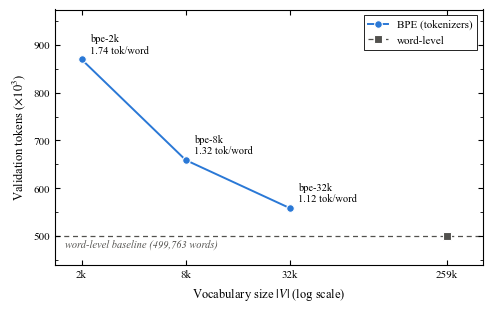

In [15]:
# TODO: scatter vocabulary size against the validation token count
#       and save it to results/26_vocab_vs_tokens.png.
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

BLUE, GRAY = "#2a78d6", "#52514e"
paper = {
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix", "font.size": 9,
    "axes.linewidth": 0.8, "axes.labelsize": 9,
    "xtick.direction": "in", "ytick.direction": "in", "xtick.top": True, "ytick.right": True,
    "xtick.major.size": 3.5, "ytick.major.size": 3.5, "xtick.minor.size": 2, "ytick.minor.size": 2,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
}

bpe_rows = [r for r in tok_table if r["tokenizer"] != "word-level"]
word_row = next(r for r in tok_table if r["tokenizer"] == "word-level")
n_words = word_row["valid_tokens"]
vocabs = [r["vocab"] for r in tok_table]

with mpl.rc_context(paper):
    fig, ax = plt.subplots(figsize=(4.8, 3.0))
    ax.axhline(n_words, color=GRAY, linewidth=0.9, linestyle=(0, (4, 3)), zorder=1)
    ax.plot([r["vocab"] for r in bpe_rows], [r["valid_tokens"] for r in bpe_rows],
            color=BLUE, linewidth=1.4, marker="o", markersize=5.5,
            markerfacecolor=BLUE, markeredgecolor="white", markeredgewidth=0.8,
            label="BPE (tokenizers)", zorder=3)
    ax.plot(word_row["vocab"], n_words, linestyle="none", marker="s", markersize=5.5,
            color=GRAY, markeredgecolor="white", markeredgewidth=0.8, zorder=3)
    ax.plot([], [], color=GRAY, linewidth=0.9, linestyle=(0, (4, 3)), marker="s", markersize=5.5,
            markeredgecolor="white", markeredgewidth=0.8, label="word-level")

    for r in bpe_rows:
        ax.annotate("%s\n%.2f tok/word" % (r["tokenizer"], r["valid_tokens"] / n_words),
                    (r["vocab"], r["valid_tokens"]), textcoords="offset points", xytext=(6, 3),
                    ha="left", va="bottom", fontsize=7.5, linespacing=1.15)
    ax.annotate("word-level baseline (%s words)" % f"{n_words:,}", (min(vocabs) * 0.8, n_words),
                textcoords="offset points", xytext=(0, -3), ha="left", va="top",
                fontsize=7.5, color=GRAY, style="italic")

    ax.set_xscale("log")
    ax.set_xticks(vocabs)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: "%dk" % round(v / 1000) if v >= 1000 else "%d" % v))
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: "%d" % round(v / 1000)))
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.set_xlim(min(vocabs) * 0.7, max(vocabs) * 1.6)
    top = max(r["valid_tokens"] for r in tok_table)
    ax.set_ylim(n_words * 0.88, top * 1.12)
    ax.set_xlabel(r"Vocabulary size $|V|$ (log scale)")
    ax.set_ylabel(r"Validation tokens ($\times 10^3$)")
    ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor="black",
              framealpha=1, borderpad=0.4, handlelength=1.8).get_frame().set_linewidth(0.6)

    fig.tight_layout(pad=0.3)
    fig.savefig("results/26_vocab_vs_tokens.png", dpi=300)
    plt.show()

### 2-7. Hyper-parameter sweep

Retrain one model at three values of `window` or `vector_size`.
The resulting table answers **question 2-7**.

In [18]:
sweep_rows = []
# TODO: retrain at three values of window or vector_size and tabulate the scores.
for window in [2, 5, 10]:
    t0 = time.time()
    m = Word2Vec(sentences=H.WordSentences(TRAIN), **dict(W2V, window=window))
    sec = time.time() - t0
    kv, _ = H.restrict_kv(m.wv, CANDIDATES)
    res = H.evaluate(kv)
    sweep_rows.append({"model": "word-level", "window": window,
                       "analogy_acc": round(float(res["analogy_acc"]), 4),
                       "wordsim_spearman": round(float(res["wordsim_spearman"]), 4),
                       "train_sec": round(sec, 1)})
    print(sweep_rows[-1])
H.save_table(sweep_rows, "results/27_sweep.csv")

{'model': 'word-level', 'window': 2, 'analogy_acc': 0.0832, 'wordsim_spearman': 0.2503, 'train_sec': 27.3}
{'model': 'word-level', 'window': 5, 'analogy_acc': 0.1276, 'wordsim_spearman': 0.3255, 'train_sec': 34.2}
{'model': 'word-level', 'window': 10, 'analogy_acc': 0.152, 'wordsim_spearman': 0.3876, 'train_sec': 40.1}


'results/27_sweep.csv'

---
## Part 3. Discussion

No code. Questions 3-1 and 3-2 in `report_template.docx` are answered from the
tables this notebook produced, above all `results/25b_sections.csv` and
`results/26_summary.csv`.

---
## Before submitting

- [ ] `python test_bpe_public.py` passes
- [ ] `results/` holds the CSV files and the PNG
- [ ] every question in `report_template.docx` is answered
- [ ] the notebook runs top to bottom without error
- [ ] the corpus files and model binaries are excluded